# 🚀 Multi-Model Image Classification Pipeline
### Kaggle-Ready | LeNet · AlexNet · MobileNetV2 · SVM · Random Forest
> **Automatic best-model selection based on F1-score and accuracy.**
---

## 1. 📦 Imports & Environment Setup

In [1]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os, warnings, random, time, pickle, json
from pathlib import Path
from typing import Dict, List, Tuple, Optional

# ── Numerical / Data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Deep Learning ─────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing import image as keras_image

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score,
                             recall_score)
from sklearn.model_selection import train_test_split as sk_split
import joblib

# ── Misc ──────────────────────────────────────────────────────────────────────
from PIL import Image, UnidentifiedImageError
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU Detection ─────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅  {len(gpus)} GPU(s) detected: {[g.name for g in gpus]}")
else:
    print("⚠️  No GPU detected – running on CPU (training will be slower)")

print(f"TensorFlow version : {tf.__version__}")


2026-04-12 19:55:38.524429: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776023738.909905      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776023739.025785      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776023740.022171      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776023740.022213      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776023740.022216      23 computation_placer.cc:177] computation placer alr

✅  2 GPU(s) detected: ['/physical_device:GPU:0', '/physical_device:GPU:1']
TensorFlow version : 2.19.0


## 2. ⚙️ Global Configuration

In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║                    EDIT THESE PATHS / PARAMS                     ║
# ╚══════════════════════════════════════════════════════════════════╝

# Path to dataset root (class-wise sub-folders inside)
DATASET_PATH = "/kaggle/input/datasets/shanmukhadattaboda/facial-skin-disease-dataset/data"   # ← change this

# Train / Validation / Test split ratios (must sum to 1.0)
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Training hyper-parameters
BATCH_SIZE  = 32
EPOCHS_CNN  = 40       # max epochs for CNN models (early-stopping active)
EPOCHS_TUNE = 10       # fine-tuning epochs for MobileNetV2

# Image sizes per model
IMG_SIZE_LENET   = (32, 32)
IMG_SIZE_STANDARD = (224, 224)

# Output directory (all saved models / plots go here)
OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Derived paths
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR  = OUTPUT_DIR / "plots"
MODEL_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

# Class names (auto-populated during data loading)
CLASS_NAMES: List[str] = []

print("Configuration ready ✔")
print(f"  Dataset path : {DATASET_PATH}")
print(f"  Output dir   : {OUTPUT_DIR}")


Configuration ready ✔
  Dataset path : /kaggle/input/datasets/shanmukhadattaboda/facial-skin-disease-dataset/data
  Output dir   : /kaggle/working/outputs


## 3. 📂 Data Loading & Splitting

In [3]:
# ─── Module: data_loader ─────────────────────────────────────────────────────

def scan_dataset(dataset_path: str) -> Tuple[List[str], List[int], List[str]]:
    """
    Walk the dataset root; collect valid image paths and integer labels.
    Corrupted / unreadable images are silently skipped.

    Returns
    -------
    file_paths : list of absolute path strings
    labels     : corresponding integer class indices
    class_names: sorted list of class folder names
    """
    dataset_path = Path(dataset_path)
    supported_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"}

    class_dirs = sorted([d for d in dataset_path.iterdir() if d.is_dir()])
    if not class_dirs:
        raise ValueError(f"No sub-folders found in {dataset_path}")

    class_names = [d.name for d in class_dirs]
    file_paths, labels = [], []
    skipped = 0

    for idx, cls_dir in enumerate(class_dirs):
        for img_path in cls_dir.rglob("*"):
            if img_path.suffix.lower() not in supported_ext:
                continue
            # ── Integrity check ──────────────────────────────────────────────
            try:
                with Image.open(img_path) as im:
                    im.verify()          # fast header check
            except (UnidentifiedImageError, Exception):
                skipped += 1
                continue
            file_paths.append(str(img_path))
            labels.append(idx)

    print(f"✅  Dataset scanned")
    print(f"    Classes  : {class_names}")
    print(f"    Valid    : {len(file_paths):,} images")
    print(f"    Skipped  : {skipped:,} corrupted images")
    return file_paths, labels, class_names


def split_dataset(
    file_paths: List[str],
    labels: List[int],
    train_ratio: float = 0.70,
    val_ratio: float   = 0.15,
    seed: int          = 42,
) -> Dict[str, Tuple[List[str], List[int]]]:
    """
    Stratified split → train / val / test.
    """
    test_ratio = 1.0 - train_ratio - val_ratio

    X_train, X_tmp, y_train, y_tmp = sk_split(
        file_paths, labels,
        test_size=1 - train_ratio,
        stratify=labels, random_state=seed)

    rel_test = test_ratio / (val_ratio + test_ratio)
    X_val, X_test, y_val, y_test = sk_split(
        X_tmp, y_tmp,
        test_size=rel_test,
        stratify=y_tmp, random_state=seed)

    splits = {"train": (X_train, y_train),
              "val":   (X_val,   y_val),
              "test":  (X_test,  y_test)}

    for name, (x, y) in splits.items():
        print(f"  {name:5s}: {len(x):6,} images")
    return splits


# ── Execute data loading ──────────────────────────────────────────────────────
all_paths, all_labels, CLASS_NAMES = scan_dataset(DATASET_PATH)
NUM_CLASSES = len(CLASS_NAMES)
data_splits = split_dataset(all_paths, all_labels, TRAIN_RATIO, VAL_RATIO)

print(f"\nNumber of classes : {NUM_CLASSES}")


✅  Dataset scanned
    Classes  : ['Acne', 'Acne_Scars', 'Contact_Dermatitis', 'Eczema_Atopic_Dermatitis', 'Folliculitis', 'Fungal_Infection_Tinea_Facei', 'Hyperpigmentation', 'NormalSkin', 'Pseudofolliculitis_Barbae', 'Rosacea', 'Seborrheic_Dermatitis', 'Sunburn', 'Vitiligo']
    Valid    : 6,500 images
    Skipped  : 0 corrupted images
  train:  4,549 images
  val  :    975 images
  test :    976 images

Number of classes : 13


## 4. 🔧 Preprocessing & tf.data Pipeline

In [4]:
# ─── Module: preprocessing ───────────────────────────────────────────────────

AUTOTUNE = tf.data.AUTOTUNE

# ── Augmentation layer (shared) ───────────────────────────────────────────────
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.10),
    layers.RandomBrightness(0.10),
], name="augmentation")


def _load_and_preprocess(path: tf.Tensor, label: tf.Tensor,
                         img_size: Tuple[int, int],
                         grayscale: bool = False) -> Tuple[tf.Tensor, tf.Tensor]:
    """Read → decode → resize → normalize a single image."""
    raw    = tf.io.read_file(path)
    channels = 1 if grayscale else 3
    img    = tf.image.decode_image(raw, channels=channels, expand_animations=False)
    img    = tf.image.resize(img, img_size)
    img    = tf.cast(img, tf.float32) / 255.0
    img.set_shape([img_size[0], img_size[1], channels])
    return img, label


def build_tf_dataset(
    paths: List[str],
    labels: List[int],
    img_size: Tuple[int, int],
    grayscale: bool    = False,
    augment: bool      = False,
    batch_size: int    = BATCH_SIZE,
    shuffle: bool      = True,
) -> tf.data.Dataset:
    """
    Build an optimized tf.data.Dataset for the given split.
    """
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda p, l: _load_and_preprocess(p, l, img_size, grayscale),
        num_parallel_calls=AUTOTUNE)

    if augment:
        ds = ds.map(
            lambda img, lbl: (data_augmentation(img, training=True), lbl),
            num_parallel_calls=AUTOTUNE)

    ds = (ds
          .batch(batch_size)
          .cache()
          .prefetch(AUTOTUNE))
    return ds


def make_datasets_for_model(model_name: str):
    """
    Return (train_ds, val_ds, test_ds) for the requested model.
    """
    lenet  = model_name.lower() == "lenet"
    size   = IMG_SIZE_LENET if lenet else IMG_SIZE_STANDARD
    gray   = lenet

    X_tr, y_tr = data_splits["train"]
    X_v,  y_v  = data_splits["val"]
    X_te, y_te = data_splits["test"]

    train_ds = build_tf_dataset(X_tr, y_tr, size, gray, augment=True)
    val_ds   = build_tf_dataset(X_v,  y_v,  size, gray, augment=False, shuffle=False)
    test_ds  = build_tf_dataset(X_te, y_te, size, gray, augment=False, shuffle=False)
    return train_ds, val_ds, test_ds


print("Preprocessing helpers ready ✔")


Preprocessing helpers ready ✔


I0000 00:00:1776023831.827993      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776023831.834037      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 5. 🏗️ Model Definitions

In [5]:
# ─── Module: model_definitions ───────────────────────────────────────────────

# ── A. LeNet ─────────────────────────────────────────────────────────────────
def build_lenet(num_classes: int) -> keras.Model:
    """
    Classic LeNet-5 adapted for multi-class classification.
    Input: (32, 32, 1)
    """
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE_LENET, 1)),

        layers.Conv2D(6, 5, activation="tanh", padding="same"),
        layers.AveragePooling2D(2),

        layers.Conv2D(16, 5, activation="tanh"),
        layers.AveragePooling2D(2),

        layers.Flatten(),
        layers.Dense(120, activation="tanh"),
        layers.Dense(84,  activation="tanh"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ], name="LeNet")

    model.compile(
        optimizer=optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"])
    return model


# ── B. AlexNet ───────────────────────────────────────────────────────────────
def build_alexnet(num_classes: int) -> keras.Model:
    """
    Simplified AlexNet for 224×224 RGB images.
    """
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE_STANDARD, 3)),

        # Block 1
        layers.Conv2D(96, 11, strides=4, activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(3, strides=2),

        # Block 2
        layers.Conv2D(256, 5, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(3, strides=2),

        # Block 3-5
        layers.Conv2D(384, 3, padding="same", activation="relu"),
        layers.Conv2D(384, 3, padding="same", activation="relu"),
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(3, strides=2),

        # Classifier head
        layers.Flatten(),
        layers.Dense(4096, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(4096, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ], name="AlexNet")

    model.compile(
        optimizer=optimizers.SGD(learning_rate=1e-2, momentum=0.9, nesterov=True),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"])
    return model


# ── C. MobileNetV2 (Transfer Learning + Fine-tuning) ─────────────────────────
def build_mobilenetv2(num_classes: int) -> keras.Model:
    """
    MobileNetV2 pretrained on ImageNet.
    Phase 1: train only the new head.
    Phase 2: fine-tune top layers (called after phase-1 training).
    """
    base = MobileNetV2(
        input_shape=(*IMG_SIZE_STANDARD, 3),
        include_top=False,
        weights="imagenet")
    base.trainable = False   # freeze for phase 1

    inputs  = keras.Input(shape=(*IMG_SIZE_STANDARD, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation="relu",
                           kernel_regularizer=regularizers.l2(1e-4))(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="MobileNetV2_TL")
    model.compile(
        optimizer=optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"])
    return model, base   # return base so we can unfreeze later


def fine_tune_mobilenetv2(model: keras.Model, base_model,
                           unfreeze_from: int = 100) -> keras.Model:
    """
    Unfreeze the top layers of MobileNetV2 for fine-tuning.
    """
    base_model.trainable = True
    for layer in base_model.layers[:unfreeze_from]:
        layer.trainable = False

    model.compile(
        optimizer=optimizers.Adam(1e-5),   # low LR for fine-tuning
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"])
    return model


print("Model definitions ready ✔")


Model definitions ready ✔


## 6. 🏋️ Training Utilities

In [6]:
# ─── Module: trainer ─────────────────────────────────────────────────────────

def get_callbacks(model_name: str, patience_es: int = 8,
                  patience_lr: int = 4) -> List[callbacks.Callback]:
    """Standard callbacks: ModelCheckpoint, EarlyStopping, ReduceLROnPlateau."""
    ckpt_path = str(MODEL_DIR / f"{model_name}_best.h5")
    return [
        callbacks.ModelCheckpoint(
            ckpt_path, monitor="val_accuracy",
            save_best_only=True, verbose=0),
        callbacks.EarlyStopping(
            monitor="val_loss", patience=patience_es,
            restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=patience_lr, min_lr=1e-7, verbose=1),
    ]


def train_cnn(model: keras.Model, model_name: str,
              train_ds: tf.data.Dataset, val_ds: tf.data.Dataset,
              epochs: int = EPOCHS_CNN) -> keras.callbacks.History:
    """Train a Keras model and return the history object."""
    print(f"\n{'='*60}")
    print(f"  Training : {model_name}")
    print(f"{'='*60}")
    t0 = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=get_callbacks(model_name),
        verbose=1)
    print(f"  Done in {(time.time()-t0)/60:.1f} min")
    return history


def plot_training_curves(history: keras.callbacks.History,
                         model_name: str) -> None:
    """Plot and save accuracy + loss curves for a trained CNN."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} – Training Curves", fontsize=14, fontweight="bold")

    for ax, metric, title in zip(
        axes,
        [("accuracy", "val_accuracy"), ("loss", "val_loss")],
        ["Accuracy", "Loss"]):
        train_m, val_m = metric
        ax.plot(history.history[train_m], label=f"Train {title}", linewidth=2)
        ax.plot(history.history[val_m],   label=f"Val {title}",   linewidth=2, linestyle="--")
        ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend()
        ax.grid(True, alpha=0.4)

    plt.tight_layout()
    save_path = PLOT_DIR / f"{model_name}_training_curves.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {save_path}")


print("Training utilities ready ✔")


Training utilities ready ✔


## 7. 📊 Evaluation Utilities

In [7]:
# ─── Module: evaluator ───────────────────────────────────────────────────────

results_store: Dict[str, Dict] = {}   # ← stores metrics for all models


def evaluate_keras_model(model: keras.Model, test_ds: tf.data.Dataset,
                          model_name: str) -> Dict:
    """
    Evaluate a Keras model on the test set.
    Returns a dict of metrics.
    """
    print(f"\n  Evaluating {model_name} …")
    y_true, y_pred = [], []
    for imgs, lbls in test_ds:
        preds  = model.predict(imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(lbls.numpy())

    return _compute_metrics(np.array(y_true), np.array(y_pred), model_name)


def evaluate_sklearn_model(model, X_test: np.ndarray,
                            y_test: np.ndarray, model_name: str) -> Dict:
    """Evaluate an sklearn model."""
    print(f"\n  Evaluating {model_name} …")
    y_pred = model.predict(X_test)
    return _compute_metrics(y_test, y_pred, model_name)


def _compute_metrics(y_true: np.ndarray, y_pred: np.ndarray,
                     model_name: str) -> Dict:
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    metrics = dict(accuracy=acc, f1=f1, precision=prec,
                   recall=rec, confusion_matrix=cm,
                   y_true=y_true, y_pred=y_pred)
    results_store[model_name] = metrics

    print(f"    Accuracy  : {acc:.4f}")
    print(f"    F1 (wtd)  : {f1:.4f}")
    print(f"    Precision : {prec:.4f}")
    print(f"    Recall    : {rec:.4f}")
    print("\n" + classification_report(y_true, y_pred,
                                        target_names=CLASS_NAMES, zero_division=0))
    plot_confusion_matrix(cm, model_name)
    return metrics


def plot_confusion_matrix(cm: np.ndarray, model_name: str) -> None:
    fig, ax = plt.subplots(figsize=(max(6, NUM_CLASSES), max(5, NUM_CLASSES-1)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True",      fontsize=11)
    ax.set_title(f"{model_name} – Confusion Matrix", fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_path = PLOT_DIR / f"{model_name}_confusion_matrix.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {save_path}")


print("Evaluation utilities ready ✔")


Evaluation utilities ready ✔


## 8. 🔬 Feature Extraction (for SVM & Random Forest)

In [8]:
# ─── Module: feature_extractor ───────────────────────────────────────────────

def build_feature_extractor() -> keras.Model:
    """
    MobileNetV2 backbone → GlobalAveragePooling → 1280-D feature vector.
    """
    base = MobileNetV2(
        input_shape=(*IMG_SIZE_STANDARD, 3),
        include_top=False,
        weights="imagenet")
    base.trainable = False

    inputs  = keras.Input(shape=(*IMG_SIZE_STANDARD, 3))
    x       = base(inputs, training=False)
    outputs = layers.GlobalAveragePooling2D()(x)
    extractor = keras.Model(inputs, outputs, name="FeatureExtractor")
    print(f"Feature extractor ready – output dim: {extractor.output_shape[-1]}")
    return extractor


def extract_features(extractor: keras.Model,
                     paths: List[str],
                     labels: List[int],
                     batch_size: int = 32) -> Tuple[np.ndarray, np.ndarray]:
    """
    Batch-wise feature extraction from image paths.
    """
    print(f"  Extracting features from {len(paths):,} images …")
    ds = build_tf_dataset(paths, labels,
                          img_size=IMG_SIZE_STANDARD,
                          grayscale=False,
                          augment=False,
                          batch_size=batch_size,
                          shuffle=False)
    features, all_labels = [], []
    for imgs, lbls in ds:
        feats = extractor(imgs, training=False).numpy()
        features.append(feats)
        all_labels.extend(lbls.numpy())

    X = np.vstack(features)
    y = np.array(all_labels)
    print(f"  Feature matrix shape: {X.shape}")
    return X, y


# ── Extract once; reuse for both ML models ───────────────────────────────────
print("Building feature extractor …")
feature_extractor = build_feature_extractor()

X_tr, y_tr = extract_features(feature_extractor, *data_splits["train"])
X_v,  y_v  = extract_features(feature_extractor, *data_splits["val"])
X_te, y_te = extract_features(feature_extractor, *data_splits["test"])

# Combine train + val for ML training (more data)
X_ml_train = np.vstack([X_tr, X_v])
y_ml_train = np.concatenate([y_tr, y_v])

# ── Scale features ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_ml_train_scaled = scaler.fit_transform(X_ml_train)
X_te_scaled       = scaler.transform(X_te)

joblib.dump(scaler, MODEL_DIR / "feature_scaler.joblib")
print("\nFeature extraction complete ✔")


Building feature extractor …
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature extractor ready – output dim: 1280
  Extracting features from 4,549 images …


I0000 00:00:1776023835.643793      23 cuda_dnn.cc:529] Loaded cuDNN version 91002


  Feature matrix shape: (4549, 1280)
  Extracting features from 975 images …
  Feature matrix shape: (975, 1280)
  Extracting features from 976 images …
  Feature matrix shape: (976, 1280)

Feature extraction complete ✔


## 9. 🧠 Train LeNet

Model: "LeNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 13)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,081 (324.54 KB)

 Trainable params: 83,081 (324.54 KB)

 Non-trainable params: 0 (0.00 B)

...

143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0944 - loss: 2.5844 - val_accuracy: 0.0954 - val_loss: 2.5553 - learning_rate: 0.0010
Epoch 5/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0801 - loss: 2.5886 - val_accuracy: 0.0954 - val_loss: 2.5465 - learning_rate: 0.0010
Epoch 6/40
139/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0818 - loss: 2.5971

143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0821 - loss: 2.5967 - val_accuracy: 0.0985 - val_loss: 2.5422 - learning_rate: 0.0010
Epoch 7/40
139/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0862 - loss: 2.5866

143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0861 - loss: 2.5864 - val_accuracy: 0.1067 - val_loss: 2.5352 - learning_rate: 0.0010
Epoch 8/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0927 - loss: 2.5670 - val_accuracy: 0.1067 - val_loss: 2.5318 - learning_rate: 0.0010
Epoch 9/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0936 - loss: 2.5607 - val_accuracy: 0.1036 - val_loss: 2.5295 - learning_rate: 0.0010
Epoch 10/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0877 - loss: 2.5683 - val_accuracy: 0.1005 - val_loss: 2.5332 - learning_rate: 0.0010
Epoch 11/40
139/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0995 - loss: 2.5550

143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0995 - loss: 2.5547 - val_accuracy: 0.1087 - val_loss: 2.5397 - learning_rate: 0.0010
Epoch 12/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0947 - loss: 2.5540 - val_accuracy: 0.1067 - val_loss: 2.5449 - learning_rate: 0.0010
Epoch 13/40
139/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0957 - loss: 2.5568


Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0958 - loss: 2.5564 - val_accuracy: 0.1118 - val_loss: 2.5484 - learning_rate: 0.0010
Epoch 14/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1041 - loss: 2.5335 - val_accuracy: 0.1087 - val_loss: 2.5516 - learning_rate: 5.0000e-04
Epoch 15/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1034 - loss: 2.5306 - val_accuracy: 0.1077 - val_loss: 2.5520 - learning_rate: 5.0000e-04
Epoch 16/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1052 - loss: 2.5194 - val_accuracy: 0.1056 - val_loss: 2.5557 - learning_rate: 5.0000e-04
Epoch 17/40
138/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1171 - loss: 2.5171
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1171 - loss: 2.5168 - val_accuracy: 0.1067 - val_loss: 2.5611 - learning_rate: 5.0000e-04
E

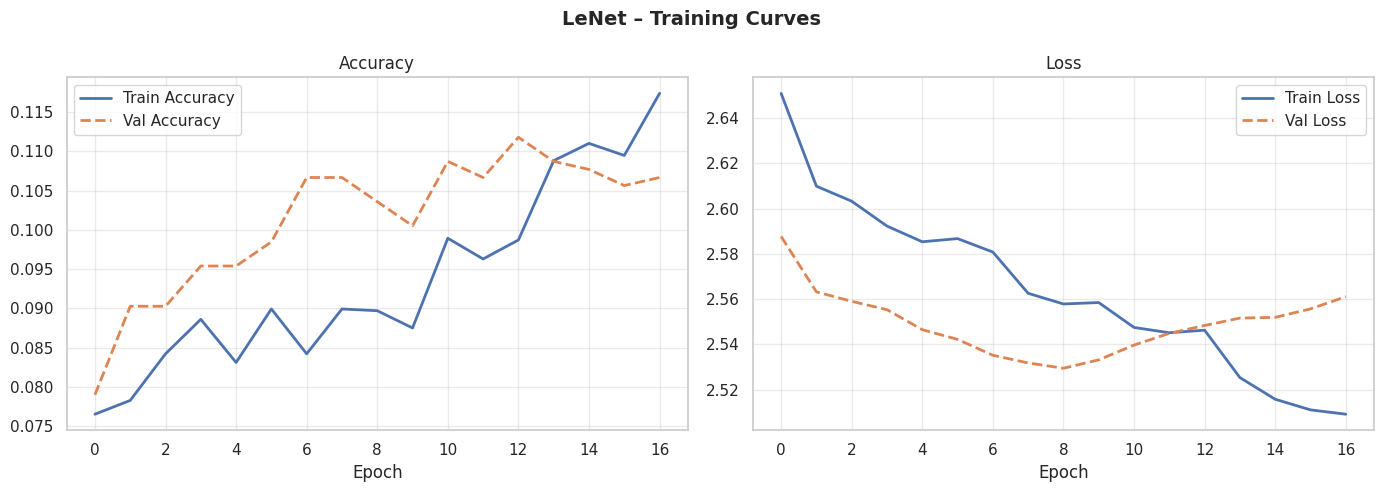

  Saved → /kaggle/working/outputs/plots/LeNet_training_curves.png

  Evaluating LeNet …
    Accuracy  : 0.1025
    F1 (wtd)  : 0.0893
    Precision : 0.1137
    Recall    : 0.1025

                              precision    recall  f1-score   support

                        Acne       0.10      0.13      0.12        75
                  Acne_Scars       0.06      0.04      0.05        75
          Contact_Dermatitis       0.08      0.11      0.09        75
    Eczema_Atopic_Dermatitis       0.10      0.29      0.14        75
                Folliculitis       0.09      0.03      0.04        75
Fungal_Infection_Tinea_Facei       0.08      0.05      0.06        75
           Hyperpigmentation       0.22      0.03      0.05        75
                  NormalSkin       0.12      0.27      0.17        75
   Pseudofolliculitis_Barbae       0.14      0.04      0.06        75
                     Rosacea       0.16      0.05      0.08        76
       Seborrheic_Dermatitis       0.07      0.0

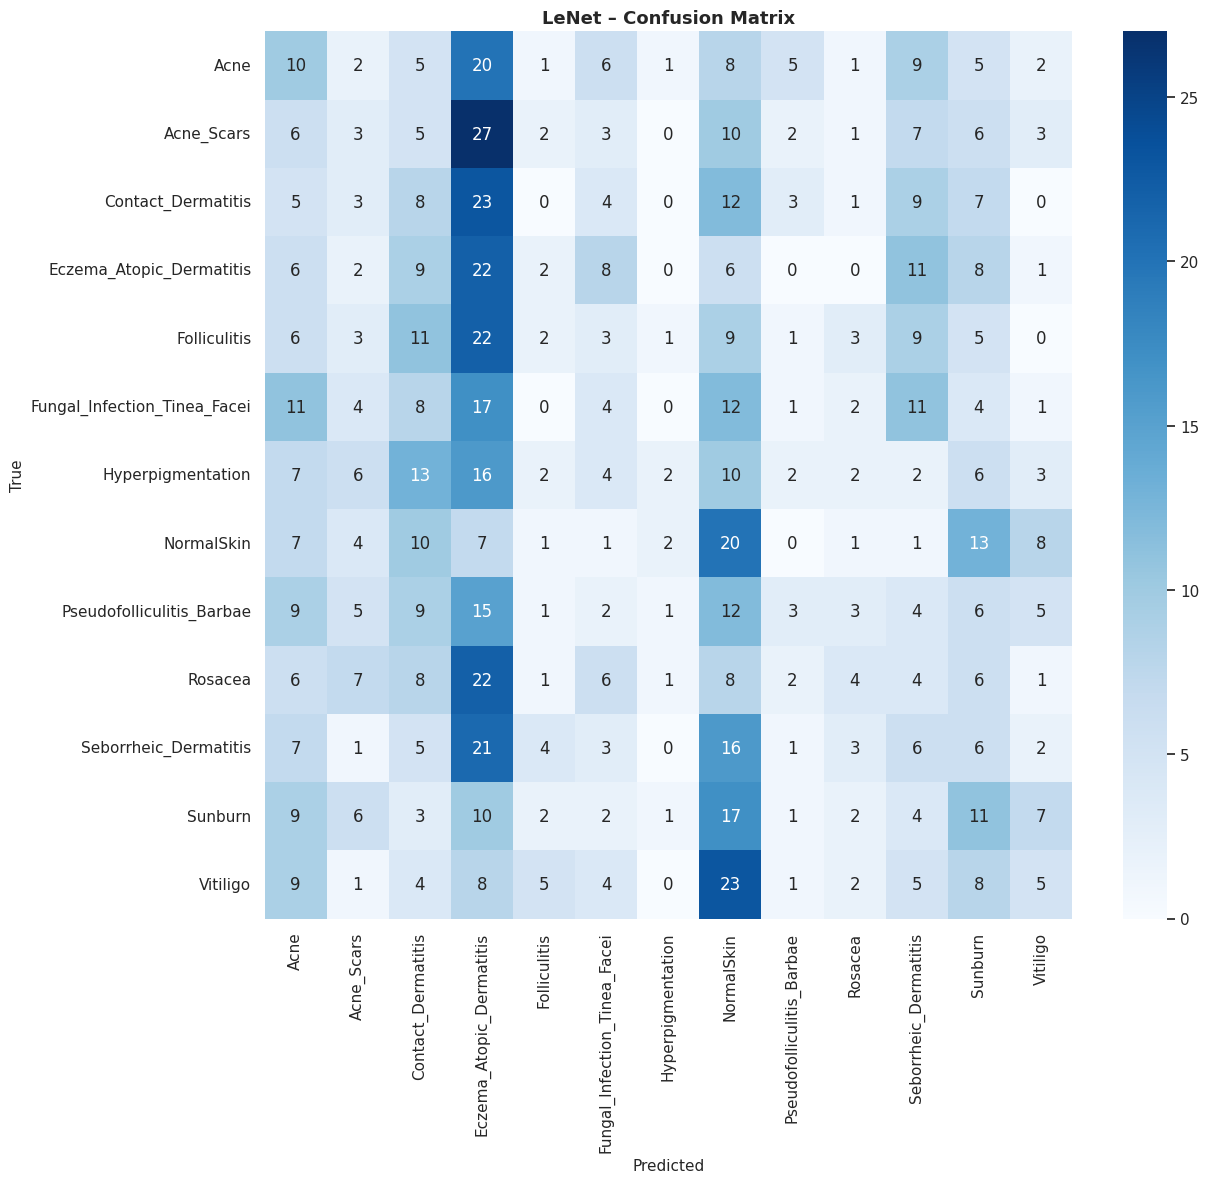

  Saved → /kaggle/working/outputs/plots/LeNet_confusion_matrix.png


In [9]:
train_ds_ln, val_ds_ln, test_ds_ln = make_datasets_for_model("lenet")

lenet_model = build_lenet(NUM_CLASSES)
lenet_model.summary()

lenet_history = train_cnn(lenet_model, "LeNet", train_ds_ln, val_ds_ln, EPOCHS_CNN)
plot_training_curves(lenet_history, "LeNet")
lenet_metrics = evaluate_keras_model(lenet_model, test_ds_ln, "LeNet")


## 10. 🧠 Train AlexNet

Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 13)             │        53,261 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,801,677 (178.53 MB)

 Trainable params: 46,800,973 (178.53 MB)

 Non-trainable params: 704 (2.75 KB)


  Training : AlexNet
Epoch 1/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.0711 - loss: 3.5800

143/143 ━━━━━━━━━━━━━━━━━━━━ 58s 343ms/step - accuracy: 0.0711 - loss: 3.5795 - val_accuracy: 0.0769 - val_loss: 3.4712 - learning_rate: 0.0100
Epoch 2/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.0760 - loss: 3.4719 - val_accuracy: 0.0769 - val_loss: 3.4660 - learning_rate: 0.0100
Epoch 3/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.0699 - loss: 3.4665 - val_accuracy: 0.0769 - val_loss: 3.4607 - learning_rate: 0.0100
Epoch 4/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.0734 - loss: 3.4620 - val_accuracy: 0.0769 - val_loss: 3.4558 - learning_rate: 0.0100
Epoch 5/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.0775 - loss: 3.4551 - val_accuracy: 0.0769 - val_loss: 3.4510 - learning_rate: 0.0100
Epoch 6/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.0781 - loss: 3.4509 - val_accuracy: 0.0769 - val_loss: 3.4460 - learning_rate: 0.0100
Epoch 7/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.0703 - loss: 3.4465 - va

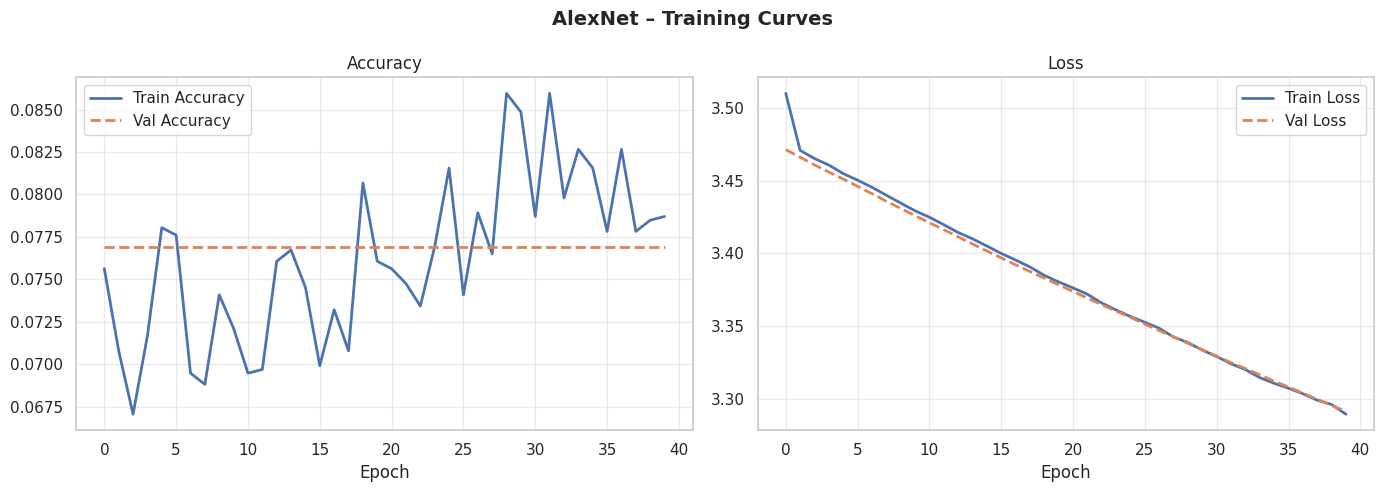

  Saved → /kaggle/working/outputs/plots/AlexNet_training_curves.png

  Evaluating AlexNet …
    Accuracy  : 0.0768
    F1 (wtd)  : 0.0110
    Precision : 0.0059
    Recall    : 0.0768

                              precision    recall  f1-score   support

                        Acne       0.00      0.00      0.00        75
                  Acne_Scars       0.00      0.00      0.00        75
          Contact_Dermatitis       0.00      0.00      0.00        75
    Eczema_Atopic_Dermatitis       0.00      0.00      0.00        75
                Folliculitis       0.00      0.00      0.00        75
Fungal_Infection_Tinea_Facei       0.00      0.00      0.00        75
           Hyperpigmentation       0.08      1.00      0.14        75
                  NormalSkin       0.00      0.00      0.00        75
   Pseudofolliculitis_Barbae       0.00      0.00      0.00        75
                     Rosacea       0.00      0.00      0.00        76
       Seborrheic_Dermatitis       0.00     

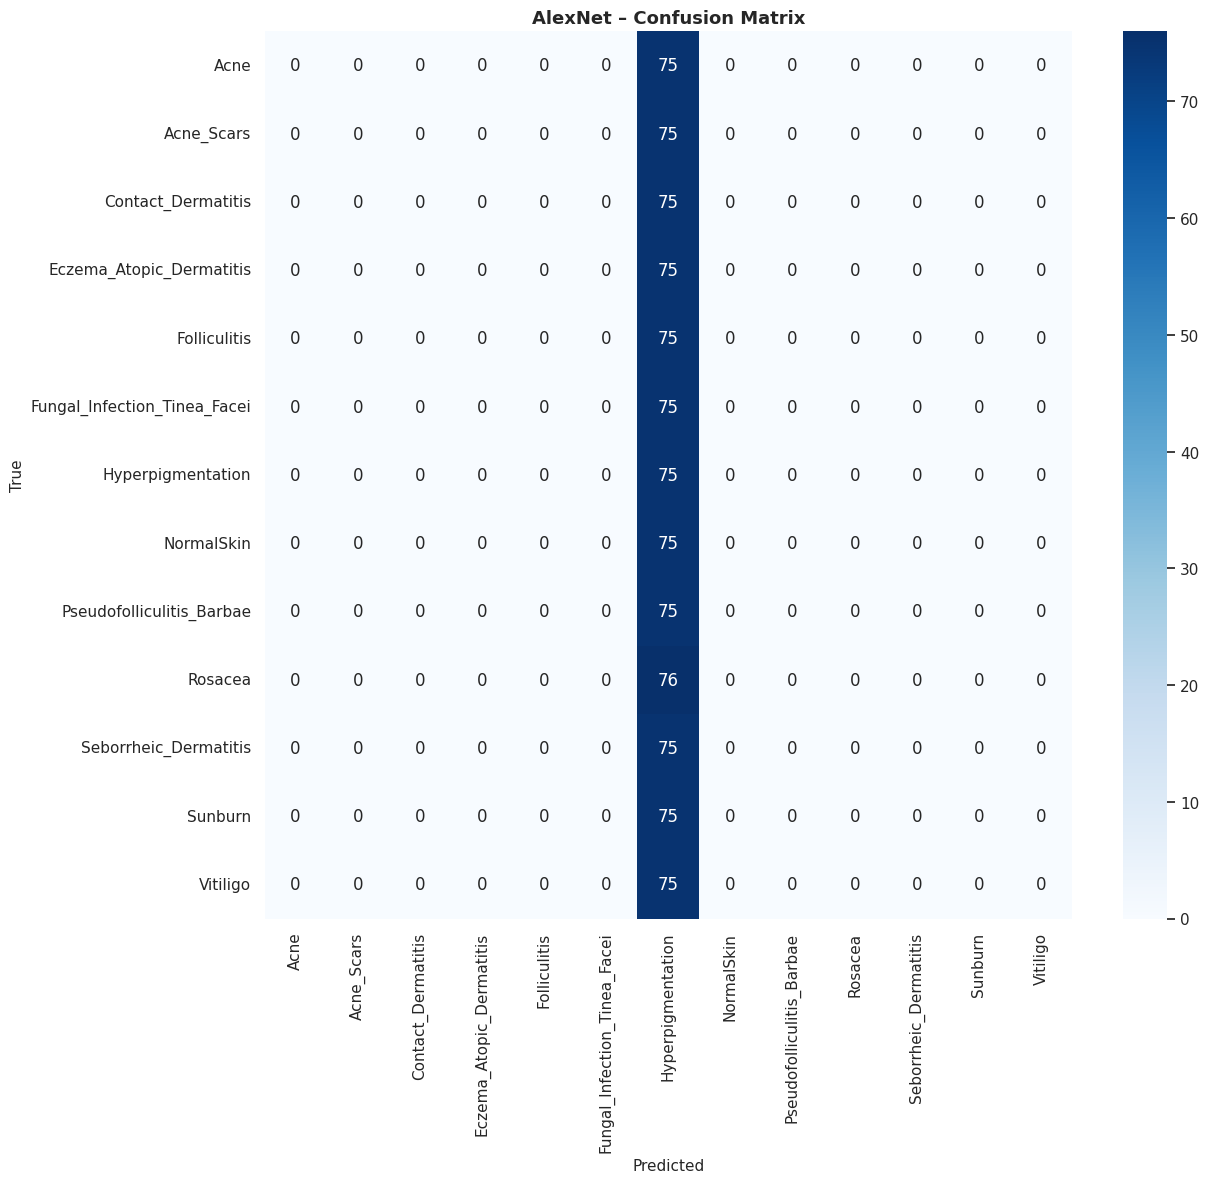

  Saved → /kaggle/working/outputs/plots/AlexNet_confusion_matrix.png


In [10]:
train_ds_ax, val_ds_ax, test_ds_ax = make_datasets_for_model("alexnet")

alexnet_model = build_alexnet(NUM_CLASSES)
alexnet_model.summary()

alexnet_history = train_cnn(alexnet_model, "AlexNet", train_ds_ax, val_ds_ax, EPOCHS_CNN)
plot_training_curves(alexnet_history, "AlexNet")
alexnet_metrics = evaluate_keras_model(alexnet_model, test_ds_ax, "AlexNet")


## 11. 🧠 Train MobileNetV2 (Transfer Learning + Fine-Tuning)

Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 13)             │         3,341 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,381 (9.90 MB)

 Trainable params: 333,837 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

...

143/143 ━━━━━━━━━━━━━━━━━━━━ 45s 172ms/step - accuracy: 0.0893 - loss: 3.1437 - val_accuracy: 0.0882 - val_loss: 3.0890 - learning_rate: 1.0000e-05
Epoch 2/10
142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1149 - loss: 2.7937

143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.1150 - loss: 2.7937 - val_accuracy: 0.0995 - val_loss: 3.2484 - learning_rate: 1.0000e-05
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.1467 - loss: 2.6282 - val_accuracy: 0.0985 - val_loss: 3.2461 - learning_rate: 1.0000e-05
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1791 - loss: 2.4881

143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.1791 - loss: 2.4881 - val_accuracy: 0.1159 - val_loss: 3.1716 - learning_rate: 1.0000e-05
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1997 - loss: 2.3616


Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.1998 - loss: 2.3616 - val_accuracy: 0.1231 - val_loss: 3.0928 - learning_rate: 1.0000e-05
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2436 - loss: 2.2693

143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.2436 - loss: 2.2692 - val_accuracy: 0.1282 - val_loss: 3.0499 - learning_rate: 5.0000e-06
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.2779 - loss: 2.1606 - val_accuracy: 0.1282 - val_loss: 3.0232 - learning_rate: 5.0000e-06
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.2841 - loss: 2.1383 - val_accuracy: 0.1210 - val_loss: 3.0092 - learning_rate: 5.0000e-06
Epoch 9/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.2995 - loss: 2.1076 - val_accuracy: 0.1200 - val_loss: 2.9884 - learning_rate: 5.0000e-06
Epoch 10/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.3273 - loss: 2.0405 - val_accuracy: 0.1210 - val_loss: 2.9855 - learning_rate: 5.0000e-06
Restoring model weights from the end of the best epoch: 10.
  Done in 1.8 min


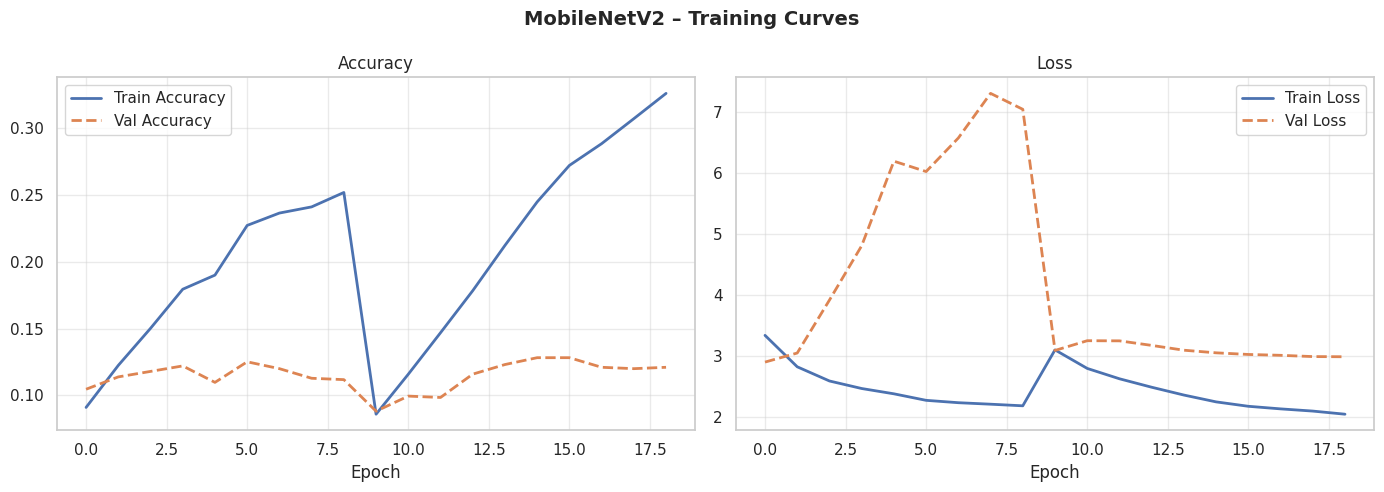

  Saved → /kaggle/working/outputs/plots/MobileNetV2_training_curves.png

  Evaluating MobileNetV2 …


2026-04-12 20:08:00.179188: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 20:08:00.317161: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 20:08:00.453723: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


    Accuracy  : 0.1117
    F1 (wtd)  : 0.1045
    Precision : 0.1385
    Recall    : 0.1117

                              precision    recall  f1-score   support

                        Acne       0.09      0.35      0.15        75
                  Acne_Scars       0.16      0.11      0.13        75
          Contact_Dermatitis       0.07      0.09      0.08        75
    Eczema_Atopic_Dermatitis       0.06      0.05      0.06        75
                Folliculitis       0.04      0.03      0.03        75
Fungal_Infection_Tinea_Facei       0.08      0.11      0.09        75
           Hyperpigmentation       0.12      0.19      0.15        75
                  NormalSkin       0.24      0.19      0.21        75
   Pseudofolliculitis_Barbae       0.14      0.13      0.13        75
                     Rosacea       0.00      0.00      0.00        76
       Seborrheic_Dermatitis       0.15      0.05      0.08        75
                     Sunburn       0.22      0.07      0.10       

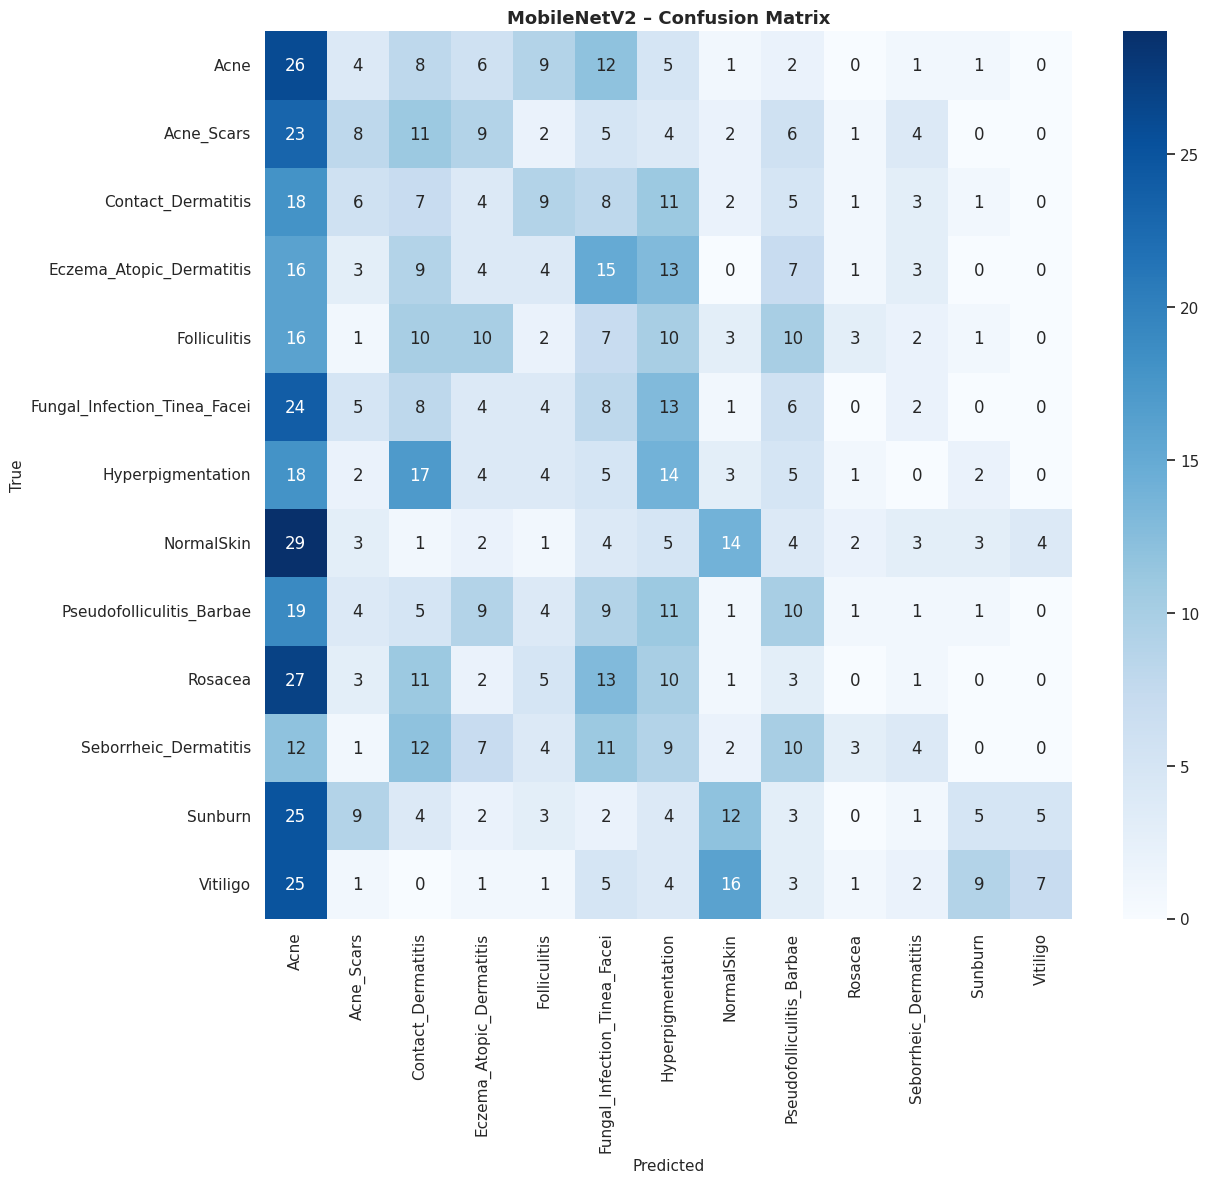

  Saved → /kaggle/working/outputs/plots/MobileNetV2_confusion_matrix.png
MobileNetV2 saved ✔


In [11]:
train_ds_mv, val_ds_mv, test_ds_mv = make_datasets_for_model("mobilenetv2")

mnv2_model, mnv2_base = build_mobilenetv2(NUM_CLASSES)
mnv2_model.summary()

# ── Phase 1: Frozen base ──────────────────────────────────────────────────────
print("\n── Phase 1: Training head only ──────────────────────────────────────")
mnv2_h1 = train_cnn(mnv2_model, "MobileNetV2_Phase1", train_ds_mv, val_ds_mv, EPOCHS_CNN)

# ── Phase 2: Fine-tuning ──────────────────────────────────────────────────────
print("\n── Phase 2: Fine-tuning top layers ──────────────────────────────────")
mnv2_model = fine_tune_mobilenetv2(mnv2_model, mnv2_base, unfreeze_from=100)
mnv2_h2 = train_cnn(mnv2_model, "MobileNetV2", train_ds_mv, val_ds_mv, EPOCHS_TUNE)

# ── Merge history for plotting ────────────────────────────────────────────────
class MergedHistory:
    def __init__(self, h1, h2):
        self.history = {k: h1.history[k] + h2.history[k] for k in h1.history}

plot_training_curves(MergedHistory(mnv2_h1, mnv2_h2), "MobileNetV2")
mnv2_metrics = evaluate_keras_model(mnv2_model, test_ds_mv, "MobileNetV2")

# Save
mnv2_model.save(MODEL_DIR / "MobileNetV2_final.h5")
print("MobileNetV2 saved ✔")


## 12. 🤖 Train SVM (on deep features)

Training SVM …
  Done in 2.0 min

  Evaluating SVM …
    Accuracy  : 0.2818
    F1 (wtd)  : 0.2821
    Precision : 0.2842
    Recall    : 0.2818

                              precision    recall  f1-score   support

                        Acne       0.16      0.19      0.17        75
                  Acne_Scars       0.22      0.25      0.24        75
          Contact_Dermatitis       0.22      0.24      0.23        75
    Eczema_Atopic_Dermatitis       0.22      0.20      0.21        75
                Folliculitis       0.23      0.19      0.20        75
Fungal_Infection_Tinea_Facei       0.17      0.19      0.18        75
           Hyperpigmentation       0.25      0.19      0.21        75
                  NormalSkin       0.42      0.44      0.43        75
   Pseudofolliculitis_Barbae       0.32      0.31      0.31        75
                     Rosacea       0.34      0.32      0.33        76
       Seborrheic_Dermatitis       0.18      0.19      0.18        75
             

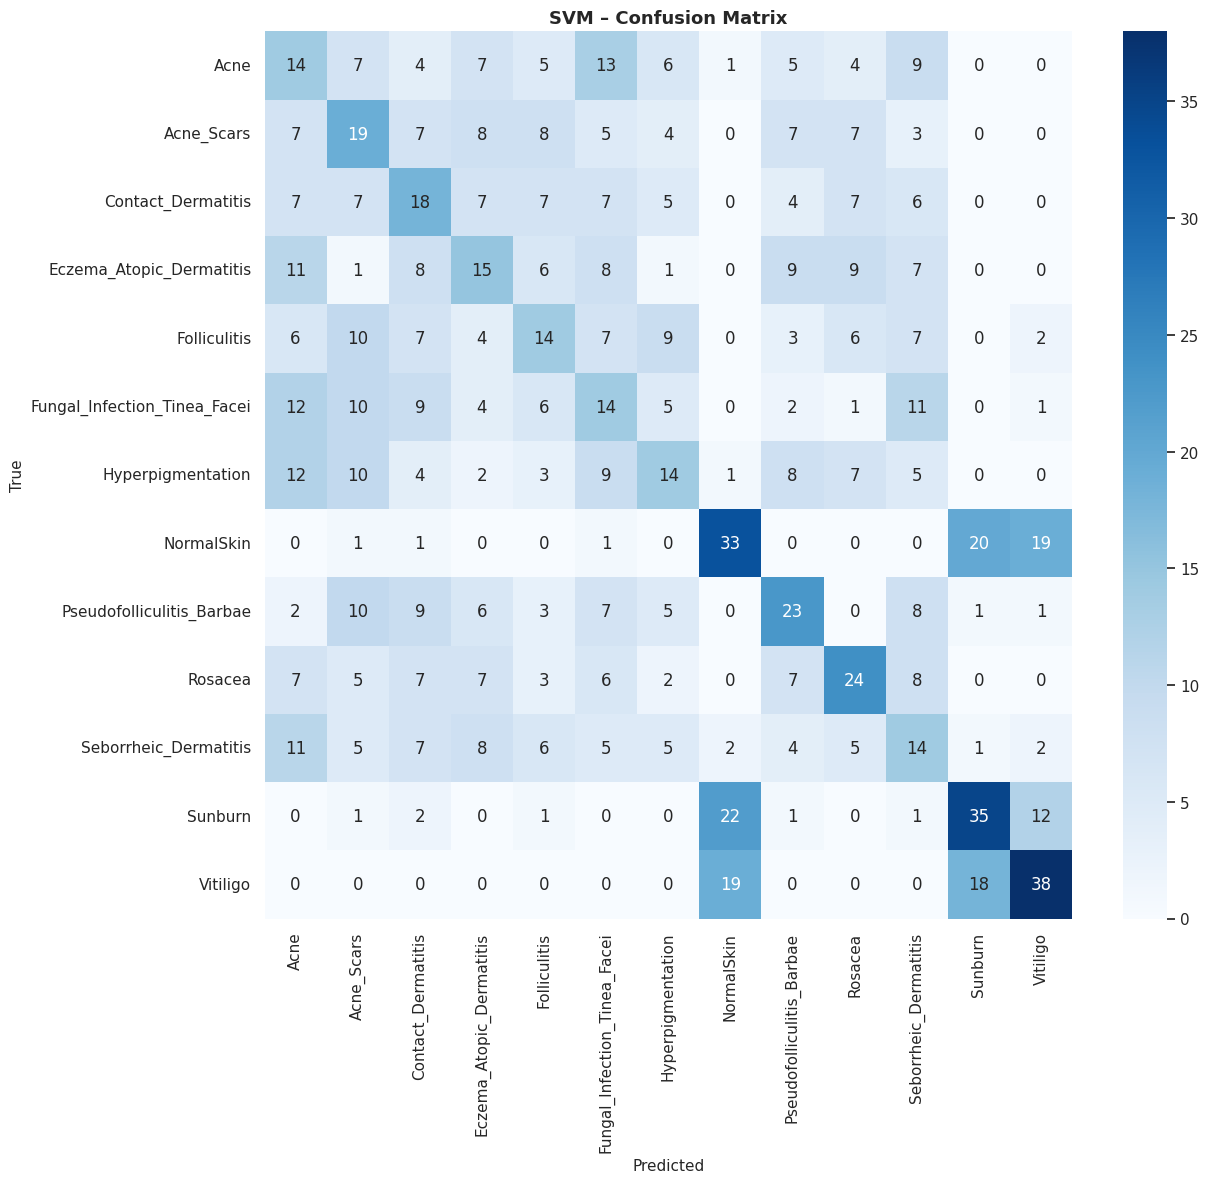

  Saved → /kaggle/working/outputs/plots/SVM_confusion_matrix.png


In [12]:
print("Training SVM …")
t0 = time.time()

svm_model = SVC(
    kernel="rbf",
    C=10.0,
    gamma="scale",
    decision_function_shape="ovr",
    probability=True,
    random_state=SEED,
    verbose=False)

svm_model.fit(X_ml_train_scaled, y_ml_train)
print(f"  Done in {(time.time()-t0)/60:.1f} min")

joblib.dump(svm_model, MODEL_DIR / "SVM.joblib")
svm_metrics = evaluate_sklearn_model(svm_model, X_te_scaled, y_te, "SVM")


## 13. 🌲 Train Random Forest (on deep features)

Training Random Forest …
  Done in 0.4 min

  Evaluating RandomForest …
    Accuracy  : 0.2234
    F1 (wtd)  : 0.2205
    Precision : 0.2222
    Recall    : 0.2234

                              precision    recall  f1-score   support

                        Acne       0.12      0.13      0.12        75
                  Acne_Scars       0.18      0.24      0.21        75
          Contact_Dermatitis       0.15      0.13      0.14        75
    Eczema_Atopic_Dermatitis       0.11      0.12      0.11        75
                Folliculitis       0.15      0.11      0.12        75
Fungal_Infection_Tinea_Facei       0.09      0.07      0.08        75
           Hyperpigmentation       0.17      0.15      0.16        75
                  NormalSkin       0.39      0.49      0.44        75
   Pseudofolliculitis_Barbae       0.32      0.33      0.32        75
                     Rosacea       0.19      0.24      0.21        76
       Seborrheic_Dermatitis       0.19      0.15      0.16     

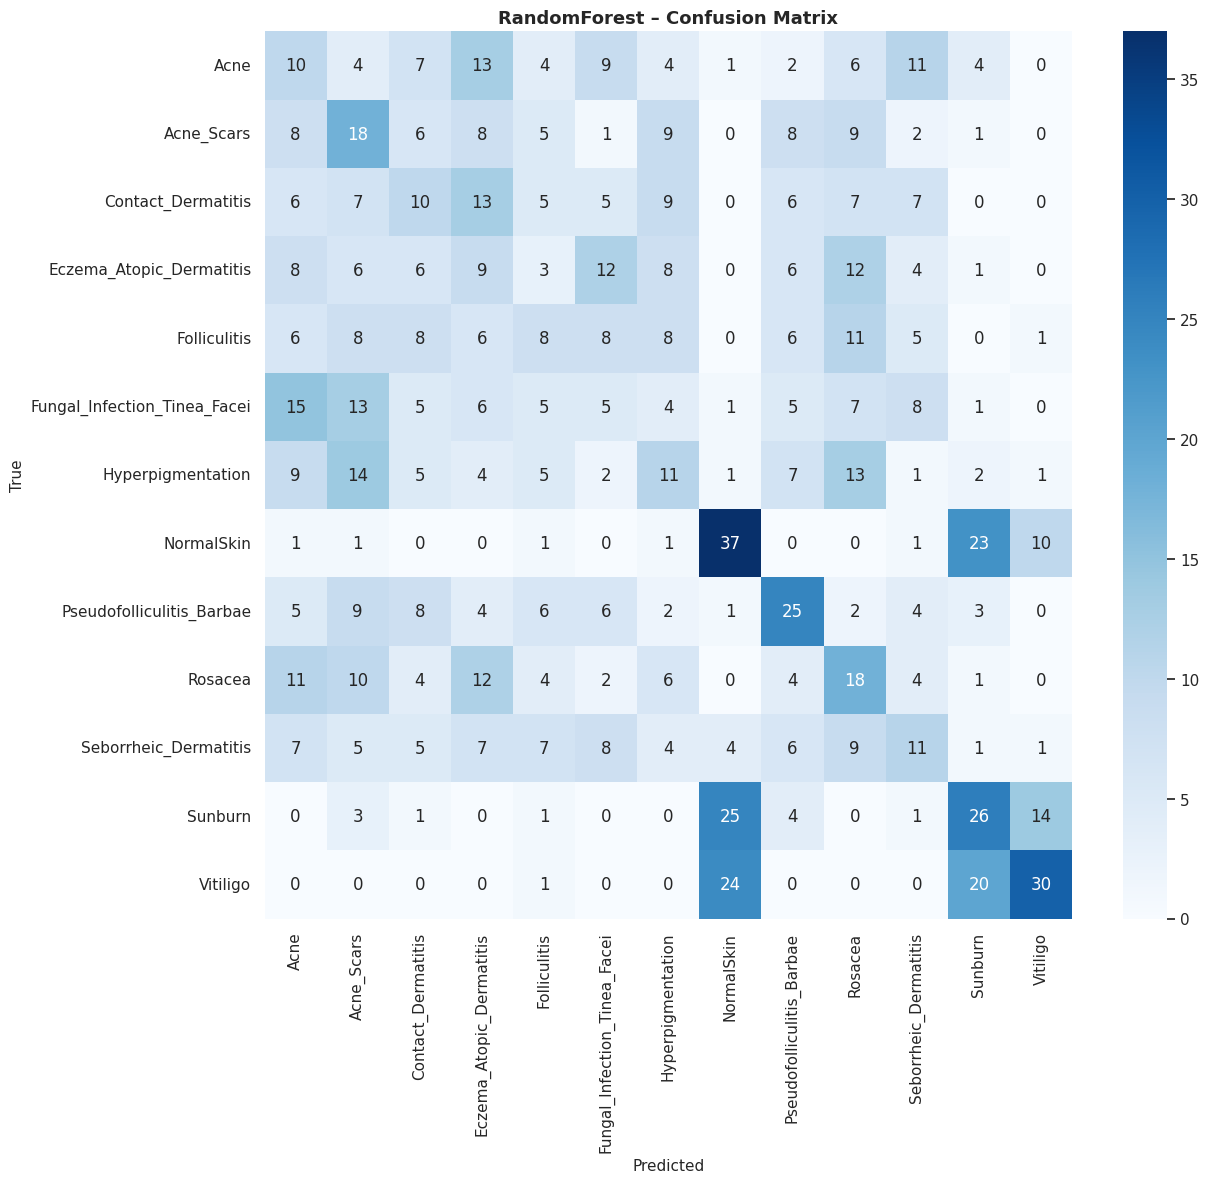

  Saved → /kaggle/working/outputs/plots/RandomForest_confusion_matrix.png


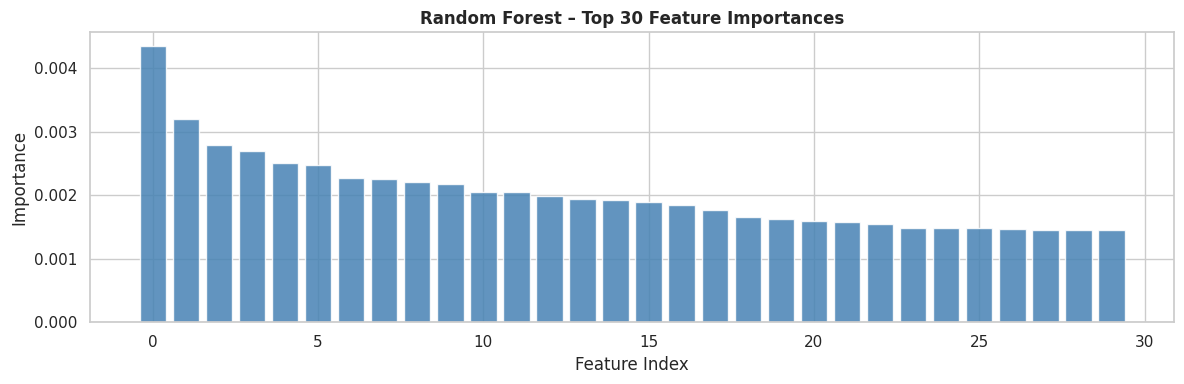

In [13]:
print("Training Random Forest …")
t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=SEED,
    verbose=0)

rf_model.fit(X_ml_train, y_ml_train)    # RF handles un-scaled features fine
print(f"  Done in {(time.time()-t0)/60:.1f} min")

joblib.dump(rf_model, MODEL_DIR / "RandomForest.joblib")
rf_metrics = evaluate_sklearn_model(rf_model, X_te, y_te, "RandomForest")

# ── Feature importance plot ───────────────────────────────────────────────────
importances = rf_model.feature_importances_
top_k       = 30
top_idx     = np.argsort(importances)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(top_k), importances[top_idx], color="steelblue", alpha=0.85)
ax.set_title(f"Random Forest – Top {top_k} Feature Importances", fontweight="bold")
ax.set_xlabel("Feature Index"); ax.set_ylabel("Importance")
plt.tight_layout()
plt.savefig(PLOT_DIR / "RandomForest_feature_importance.png", dpi=150)
plt.show()


## 14. 📈 Model Comparison & Best-Model Selection


  MODEL COMPARISON TABLE
       Model  Accuracy  F1 (wtd)  Precision  Recall
         SVM    0.2818    0.2821     0.2842  0.2818
RandomForest    0.2234    0.2205     0.2222  0.2234
 MobileNetV2    0.1117    0.1045     0.1385  0.1117
       LeNet    0.1025    0.0893     0.1137  0.1025
     AlexNet    0.0768    0.0110     0.0059  0.0768


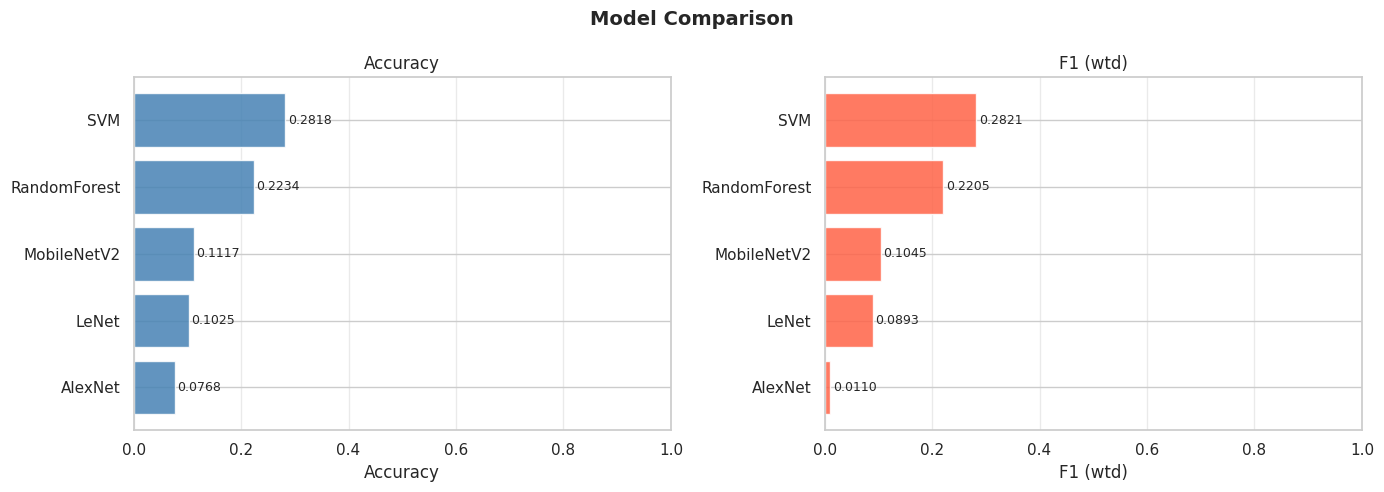


🏆  BEST MODEL : SVM
    Accuracy   : 0.2818
    F1 (wtd)   : 0.2821


In [14]:
# ─── Module: comparison ──────────────────────────────────────────────────────

# Build comparison DataFrame
rows = []
for name, m in results_store.items():
    rows.append({
        "Model"    : name,
        "Accuracy" : round(m["accuracy"],  4),
        "F1 (wtd)" : round(m["f1"],        4),
        "Precision": round(m["precision"], 4),
        "Recall"   : round(m["recall"],    4),
    })

comparison_df = pd.DataFrame(rows).sort_values("F1 (wtd)", ascending=False)
print("\n" + "="*65)
print("  MODEL COMPARISON TABLE")
print("="*65)
print(comparison_df.to_string(index=False))
print("="*65)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Comparison", fontsize=14, fontweight="bold")

for ax, col, color in zip(axes,
                           ["Accuracy", "F1 (wtd)"],
                           ["steelblue", "tomato"]):
    bars = ax.barh(comparison_df["Model"], comparison_df[col],
                   color=color, alpha=0.85, edgecolor="white")
    ax.set_xlabel(col); ax.set_title(col)
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, comparison_df[col]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=9)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.4)

plt.tight_layout()
plt.savefig(PLOT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Best model ────────────────────────────────────────────────────────────────
best_row       = comparison_df.iloc[0]
BEST_MODEL_NAME = best_row["Model"]
print(f"\n🏆  BEST MODEL : {BEST_MODEL_NAME}")
print(f"    Accuracy   : {best_row['Accuracy']:.4f}")
print(f"    F1 (wtd)   : {best_row['F1 (wtd)']:.4f}")

# Save comparison table
comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)


## 15. 💾 Save Best Model

In [15]:
# ─── Module: model_saver ─────────────────────────────────────────────────────

MODEL_REGISTRY = {
    "LeNet"      : lenet_model,
    "AlexNet"    : alexnet_model,
    "MobileNetV2": mnv2_model,
    "SVM"        : svm_model,
    "RandomForest": rf_model,
}

BEST_MODEL_PATH = str(MODEL_DIR / f"BEST_MODEL_{BEST_MODEL_NAME}")

if BEST_MODEL_NAME in ("LeNet", "AlexNet", "MobileNetV2"):
    best_obj = MODEL_REGISTRY[BEST_MODEL_NAME]
    best_obj.save(BEST_MODEL_PATH + ".h5")
    print(f"✅  Best CNN model saved → {BEST_MODEL_PATH}.h5")
else:
    best_obj = MODEL_REGISTRY[BEST_MODEL_NAME]
    joblib.dump(best_obj, BEST_MODEL_PATH + ".joblib")
    print(f"✅  Best ML model saved  → {BEST_MODEL_PATH}.joblib")

# ── Metadata JSON ─────────────────────────────────────────────────────────────
meta = {
    "best_model"  : BEST_MODEL_NAME,
    "class_names" : CLASS_NAMES,
    "img_size_lenet"   : list(IMG_SIZE_LENET),
    "img_size_standard": list(IMG_SIZE_STANDARD),
    "metrics"     : {
        name: {k: float(v) for k, v in m.items()
               if k not in ("confusion_matrix", "y_true", "y_pred")}
        for name, m in results_store.items()
    }
}
with open(OUTPUT_DIR / "pipeline_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"\nMetadata saved → {OUTPUT_DIR}/pipeline_metadata.json")


✅  Best ML model saved  → /kaggle/working/outputs/models/BEST_MODEL_SVM.joblib

Metadata saved → /kaggle/working/outputs/pipeline_metadata.json


## 16. 🔮 Unified Prediction Function

In [16]:
# ─── Module: predictor ───────────────────────────────────────────────────────

def predict_image(image_path: str,
                  best_model_name: str = BEST_MODEL_NAME) -> Dict:
    """
    Unified prediction function.
    Automatically:
      • selects image size / colour mode for the best model
      • preprocesses the image
      • returns predicted class + confidence

    Parameters
    ----------
    image_path      : path to an image file
    best_model_name : model to use (defaults to pipeline winner)

    Returns
    -------
    dict with keys: model, predicted_class, confidence, all_probabilities
    """
    is_lenet = (best_model_name == "LeNet")
    is_ml    = best_model_name in ("SVM", "RandomForest")
    size     = IMG_SIZE_LENET if is_lenet else IMG_SIZE_STANDARD
    mode     = "L" if is_lenet else "RGB"

    # ── Load & preprocess ────────────────────────────────────────────────────
    try:
        img = Image.open(image_path).convert(mode).resize(size)
    except Exception as e:
        return {"error": str(e)}

    arr = np.array(img, dtype=np.float32) / 255.0

    if is_lenet:
        arr = arr[..., np.newaxis]   # (32, 32, 1)
    arr_batch = arr[np.newaxis, ...]  # (1, H, W, C)

    # ── Predict ──────────────────────────────────────────────────────────────
    model = MODEL_REGISTRY[best_model_name]

    if is_ml:
        feat   = feature_extractor(arr_batch, training=False).numpy()
        if best_model_name == "SVM":
            feat = scaler.transform(feat)
        probs      = model.predict_proba(feat)[0]
        class_idx  = int(np.argmax(probs))
        confidence = float(probs[class_idx])
    else:
        probs      = model.predict(arr_batch, verbose=0)[0]
        class_idx  = int(np.argmax(probs))
        confidence = float(probs[class_idx])

    return {
        "model"            : best_model_name,
        "predicted_class"  : CLASS_NAMES[class_idx],
        "confidence"       : f"{confidence*100:.2f}%",
        "all_probabilities": {cn: f"{p*100:.2f}%"
                              for cn, p in zip(CLASS_NAMES, probs)},
    }


# ── Quick demo (replace path with a real image) ───────────────────────────────
demo_path = data_splits["test"][0][0]   # first test image
result    = predict_image(demo_path)
print("\n🔍  Prediction demo")
print(json.dumps({k: v for k, v in result.items()
                  if k != "all_probabilities"}, indent=2))
print("\n  Class probabilities:")
for cls, prob in result.get("all_probabilities", {}).items():
    print(f"    {cls:20s} → {prob}")



🔍  Prediction demo
{
  "model": "SVM",
  "predicted_class": "Acne",
  "confidence": "15.76%"
}

  Class probabilities:
    Acne                 → 15.76%
    Acne_Scars           → 10.28%
    Contact_Dermatitis   → 14.53%
    Eczema_Atopic_Dermatitis → 4.45%
    Folliculitis         → 14.06%
    Fungal_Infection_Tinea_Facei → 6.27%
    Hyperpigmentation    → 8.79%
    NormalSkin           → 0.06%
    Pseudofolliculitis_Barbae → 8.14%
    Rosacea              → 10.08%
    Seborrheic_Dermatitis → 7.40%
    Sunburn              → 0.12%
    Vitiligo             → 0.06%


## 17. 🎯 Pipeline Summary

In [17]:
print("\n" + "╔" + "═"*62 + "╗")
print("║" + "  PIPELINE COMPLETE".center(62) + "║")
print("╠" + "═"*62 + "╣")
for name, m in results_store.items():
    marker = "🏆" if name == BEST_MODEL_NAME else "  "
    print(f"║ {marker} {name:<20} Acc={m['accuracy']:.4f}  F1={m['f1']:.4f}     ║")
print("╠" + "═"*62 + "╣")
print(f"║  Best model : {BEST_MODEL_NAME:<46}║")
print("╠" + "═"*62 + "╣")
print(f"║  Outputs saved to : {str(OUTPUT_DIR):<40}║")
print("╚" + "═"*62 + "╝")

# List saved files
print("\n📁 Output files:")
for f in sorted(OUTPUT_DIR.rglob("*")):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"   {str(f.relative_to(OUTPUT_DIR)):50s}  {size_kb:8.1f} KB")



╔══════════════════════════════════════════════════════════════╗
║                       PIPELINE COMPLETE                      ║
╠══════════════════════════════════════════════════════════════╣
║    LeNet                Acc=0.1025  F1=0.0893     ║
║    AlexNet              Acc=0.0768  F1=0.0110     ║
║    MobileNetV2          Acc=0.1117  F1=0.1045     ║
║ 🏆 SVM                  Acc=0.2818  F1=0.2821     ║
║    RandomForest         Acc=0.2234  F1=0.2205     ║
╠══════════════════════════════════════════════════════════════╣
║  Best model : SVM                                           ║
╠══════════════════════════════════════════════════════════════╣
║  Outputs saved to : /kaggle/working/outputs                 ║
╚══════════════════════════════════════════════════════════════╝

📁 Output files:
   model_comparison.csv                                     0.2 KB
   models/AlexNet_best.h5                              365714.0 KB
   models/BEST_MODEL_SVM.joblib                         56240